## Kaggle Playground Competition (f1 Pit Stop Prediction Model)

### Introduction
This notebook presents a machine learning model designed to predict the possibility of a driver to stop at a pit stop in Formula 1

### File Description
- `train.csv`: Contains the training data with features and target variable.
- `test.csv`: Contains the test data for making predictions.

### Data Loading and Preprocessing

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, log_loss
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import TargetEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [47]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

## Finding the best model for the data

* Splitting the train and test data

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('PitNextLap', axis=1), train['PitNextLap'],
    test_size=0.2, random_state=42, stratify=train['PitNextLap']
)

* Checking relation of Compound and PitStop

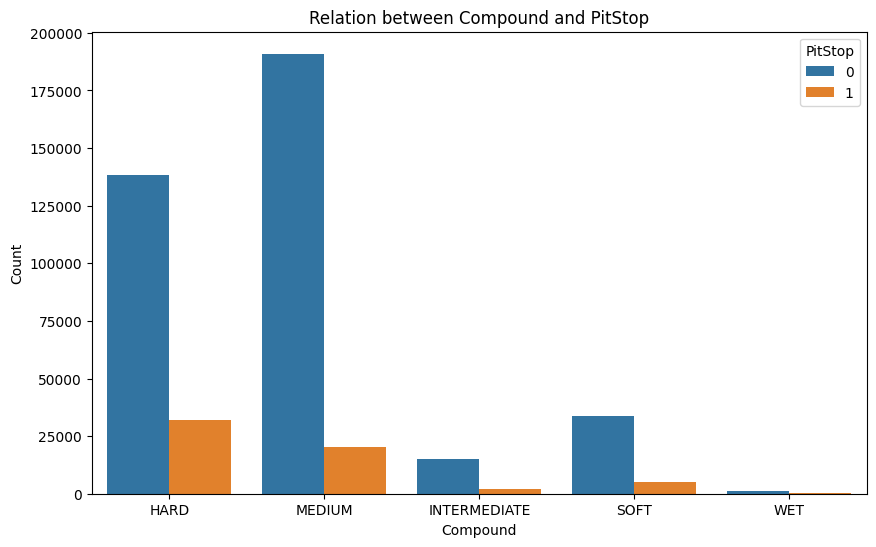

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Compound', hue='PitStop', data=train)
plt.title('Relation between Compound and PitStop')
plt.xlabel('Compound')
plt.ylabel('Count')
plt.legend(title='PitStop')
plt.show()

* Encoding the Compound feature using one-hot encoding

In [50]:
X_train = X_train.join(pd.get_dummies(X_train['Compound'], prefix='Compound', dtype=int))
X_test = X_test.join(pd.get_dummies(X_test['Compound'], prefix='Compound', dtype=int))
X_train.drop('Compound', axis=1, inplace=True)
X_test.drop('Compound', axis=1, inplace=True)

* Checking Relation of Race and PitStop

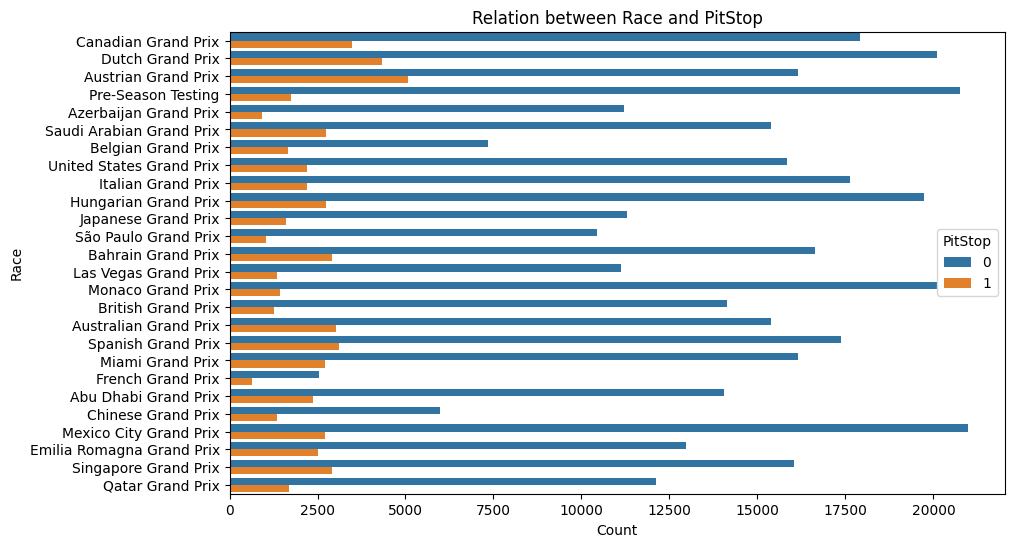

In [51]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Race', hue='PitStop', data=train)
plt.title('Relation between Race and PitStop')
plt.xlabel('Count')
plt.ylabel('Race')
plt.legend(title='PitStop')
plt.show()

In [52]:
target_encoder = TargetEncoder()
X_train['Race'] = target_encoder.fit_transform(X_train[['Race']], y_train)
X_test['Race'] = target_encoder.transform(X_test[['Race']])

* Transforming the Driver Column using Target Encoding

In [ ]:
X_train['Driver'] = target_encoder.fit_transform(X_train[['Driver']], y_train)
X_test['Driver'] = target_encoder.transform(X_test[['Driver']])

### Model Building and Evaluation

In [56]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(eval_metric='logloss', n_jobs=-1)

grid_search = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best score: -0.23101394513810464


In [57]:
best_xgb = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=300,
    subsample=0.8,
    eval_metric='logloss',
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

y_prob = best_xgb.predict_proba(X_test)[:, 1]
y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.93      0.94      0.94     70352
         1.0       0.75      0.73      0.74     17476

    accuracy                           0.90     87828
   macro avg       0.84      0.84      0.84     87828
weighted avg       0.90      0.90      0.90     87828

Log Loss: 0.22791904716635947
